# 05 — UL-DD Preprocessing

Run `ULDDProcessor` to:
1. Load FAU + Telemetry CSVs for all 19 subjects
2. Downsample 60 Hz → 4 Hz
3. Extract 60-second sliding windows (240 timesteps, stride 15 s)
4. Map KSS to 3-class labels
5. Split into 5 subject-independent folds
6. Z-score normalise per fold
7. Save `fold_0.npz` … `fold_4.npz`

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from data.preprocess import ULDDProcessor
from data.load_data   import load_fold, load_all_folds, summarise_fold, class_distribution

ULDD_ROOT = Path(r'C:/Users/raka1005/Documents/IISC/UL-DD')
OUT_DIR   = ROOT / 'datasets' / 'processed' / 'ul_dd'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'UL-DD root : {ULDD_ROOT}')
print(f'Output dir : {OUT_DIR}')

UL-DD root : C:\Users\raka1005\Documents\IISC\UL-DD
Output dir : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\datasets\processed\ul_dd


In [2]:
# ── Run full preprocessing pipeline ──────────────────────────────────────────
processor = ULDDProcessor(dataset_root=str(ULDD_ROOT), processed_dir=str(OUT_DIR))
processor.run()   # produces fold_0.npz … fold_4.npz
print('Done.')


────────────────────────────────────────────────────────────
  UL-DD Preprocessing Pipeline
  Root : C:\Users\raka1005\Documents\IISC\UL-DD
  Out  : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\datasets\processed\ul_dd
  Win  : 60s  Stride: 15s  Rate: 4 Hz
────────────────────────────────────────────────────────────

[1/3]  Processing sessions …
  A/A (Alert ) ... 156 windows | tele=✗ | cls(0/1/2)=[0, 156, 0]
  A/D (Drowsy) ... 139 windows | tele=✗ | cls(0/1/2)=[0, 14, 125]
  B/A (Alert ) ... 157 windows | tele=✓ | cls(0/1/2)=[30, 127, 0]
  B/D (Drowsy) ... 156 windows | tele=✓ | cls(0/1/2)=[0, 30, 126]
  C/A (Alert ) ... 155 windows | tele=✓ | cls(0/1/2)=[32, 123, 0]
  D/A (Alert ) ... 156 windows | tele=✓ | cls(0/1/2)=[30, 110, 16]
  D/D (Drowsy) ... 154 windows | tele=✓ | cls(0/1/2)=[0, 30, 124]
  E/A (Alert ) ... 153 windows | tele=✓ | cls(0/1/2)=[110, 43, 0]
  E/D (Drowsy) ... 132 windows | tele=✓ | cls(0/1/2)=[0, 30, 102]
  F/A (Alert ) ... 156 windows | t

In [3]:
# ── Verify saved files ────────────────────────────────────────────────────────
npz_files = sorted(OUT_DIR.glob('fold_*.npz'))
print(f'Found {len(npz_files)} fold files:')
for f in npz_files:
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name}  ({size_mb:.1f} MB)')

Found 5 fold files:
  fold_0.npz  (25.0 MB)
  fold_1.npz  (25.0 MB)
  fold_2.npz  (25.0 MB)
  fold_3.npz  (25.0 MB)
  fold_4.npz  (25.0 MB)


In [6]:
# ── Inspect each fold ─────────────────────────────────────────────────────────
folds = load_all_folds(str(OUT_DIR))
for i, fold in enumerate(folds):
    print(f'\n── Fold {i} ──────────────────')
    summarise_fold(fold)


── Fold 0 ──────────────────
──────────────────────────────────────────────────
M1  (FAU-only, all sessions):
  X_fau_train  : (4294, 240, 30)
  X_fau_test   : (1073, 240, 30)
  y_train      : (4294,)
  y_test       : (1073,)
M2/M3  (FAU + Tele, matched sessions):
  mm_fau_train : (4294, 240, 30)
  mm_tele_train: (4294, 240, 5)
  mm_y_train   : (4294,)
  mm_fau_test  : (778, 240, 30)
  mm_tele_test : (778, 240, 5)
  mm_y_test    : (778,)
──────────────────────────────────────────────────

── Fold 1 ──────────────────
──────────────────────────────────────────────────
M1  (FAU-only, all sessions):
  X_fau_train  : (4301, 240, 30)
  X_fau_test   : (1066, 240, 30)
  y_train      : (4301,)
  y_test       : (1066,)
M2/M3  (FAU + Tele, matched sessions):
  mm_fau_train : (4006, 240, 30)
  mm_tele_train: (4006, 240, 5)
  mm_y_train   : (4006,)
  mm_fau_test  : (1066, 240, 30)
  mm_tele_test : (1066, 240, 5)
  mm_y_test    : (1066,)
──────────────────────────────────────────────────

── Fold 

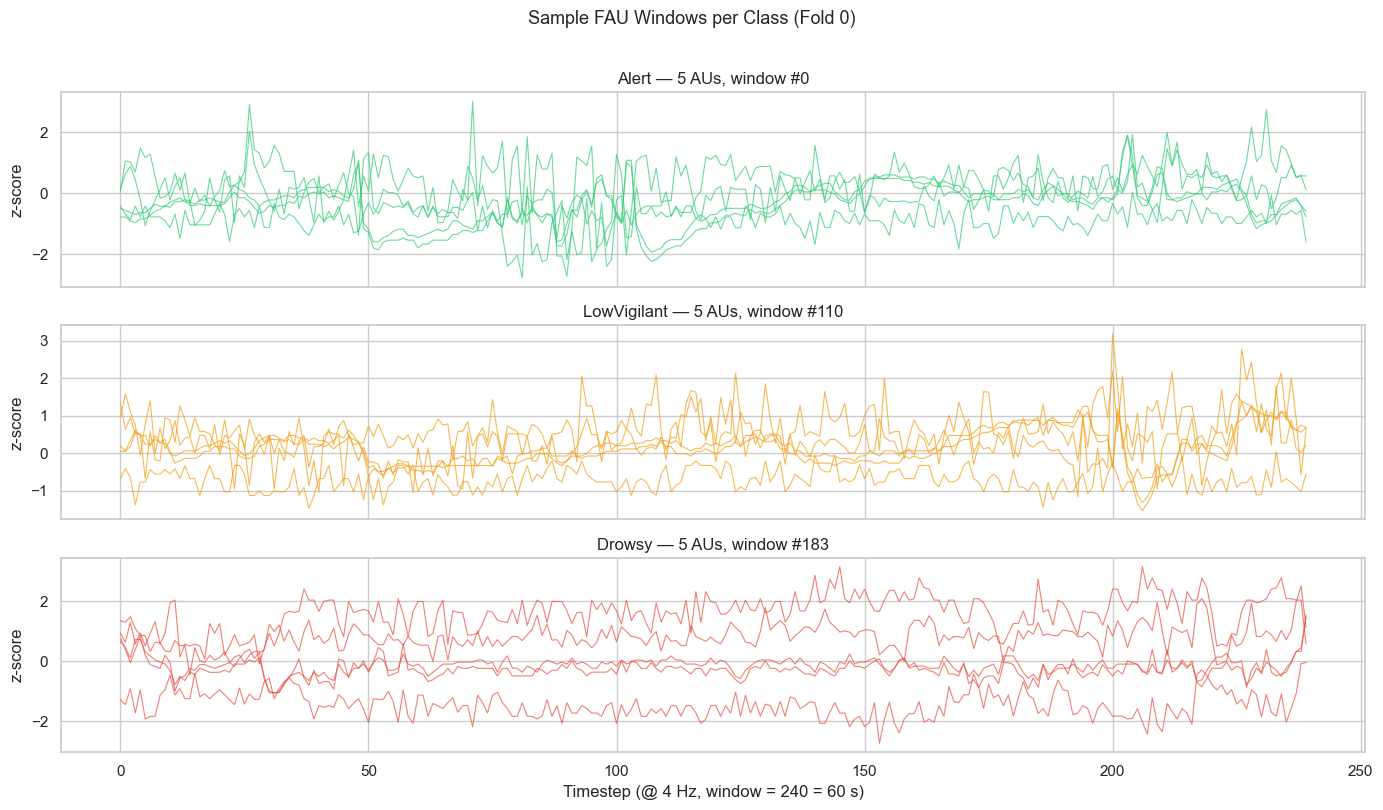

In [8]:
# ── Sample windows per class ──────────────────────────────────────────────────
fold0 = folds[0]
fau_w = fold0['X_fau_train']
labels = fold0['y_train']

CLASS_NAMES = ['Alert', 'LowVigilant', 'Drowsy']
COLORS      = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for cls, (ax, color) in enumerate(zip(axes, COLORS)):
    idx = np.where(labels == cls)[0]
    if len(idx) == 0:
        ax.set_title(f'{CLASS_NAMES[cls]} — no samples in fold 0')
        continue
    sample = fau_w[idx[0]]   # (240, 30)
    for j in range(min(5, sample.shape[1])):
        ax.plot(sample[:, j], alpha=0.7, color=color, lw=0.8)
    ax.set_title(f'{CLASS_NAMES[cls]} — 5 AUs, window #{idx[0]}')
    ax.set_ylabel('z-score')
axes[-1].set_xlabel('Timestep (@ 4 Hz, window = 240 = 60 s)')
plt.suptitle('Sample FAU Windows per Class (Fold 0)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / 'results/reports/sample_windows.png', dpi=150, bbox_inches='tight')
plt.show()

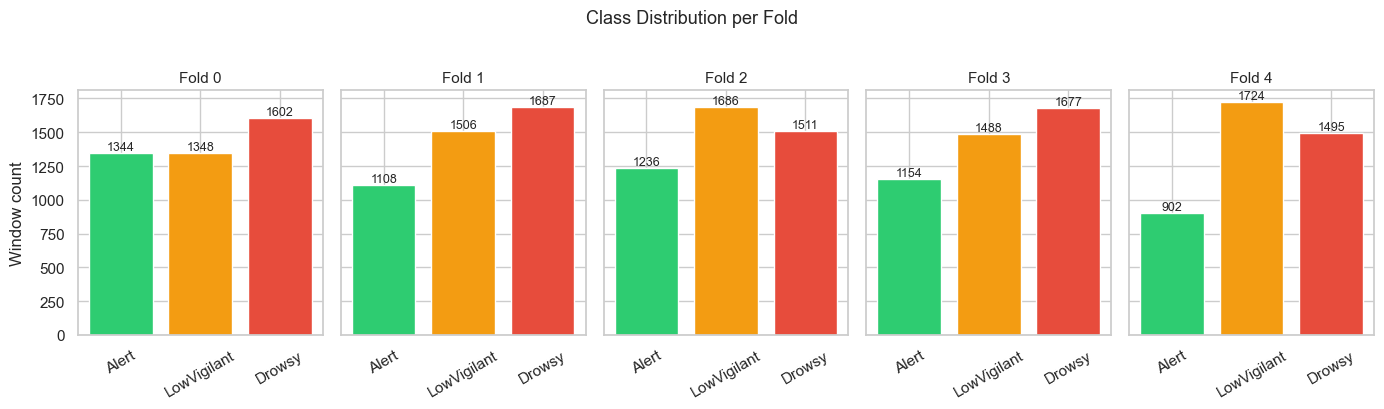

In [10]:
# ── Class balance across folds ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(folds), figsize=(14, 4), sharey=True)
for i, (fold, ax) in enumerate(zip(folds, axes)):
    vals, counts = np.unique(fold['y_train'], return_counts=True)
    bars = ax.bar([CLASS_NAMES[v] for v in vals], counts,
                  color=['#2ecc71','#f39c12','#e74c3c'][:len(vals)], edgecolor='white')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                str(cnt), ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Fold {i}', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Window count')
plt.suptitle('Class Distribution per Fold', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / 'results/reports/class_balance_folds.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Feature statistics summary ────────────────────────────────────────────────
print('=== Preprocessing Summary ===')
total_windows = sum(f['y_train'].shape[0] for f in folds)
print(f'Total windows (across all folds) : {total_windows}')
print(f'Window size                       : {folds[0]["X_fau_train"].shape[1]} timesteps (60 s @ 4 Hz)')
print(f'FAU features per timestep         : {folds[0]["X_fau_train"].shape[2]}')
print(f'Telemetry features per timestep   : {folds[0]["mm_tele_train"].shape[2]}')
print()
for i, fold in enumerate(folds):
    vals, counts = np.unique(fold['y_train'], return_counts=True)
    dist = {CLASS_NAMES[v]: int(c) for v,c in zip(vals, counts)}
    print(f'Fold {i}: {fold["y_train"].shape[0]} windows | {dist}')

=== Preprocessing Summary ===
Total windows (across all folds) : 21468
Window size                       : 240 timesteps (60 s @ 4 Hz)
FAU features per timestep         : 30
Telemetry features per timestep   : 5

Fold 0: 4294 windows | {'Alert': 1344, 'LowVigilant': 1348, 'Drowsy': 1602}
Fold 1: 4301 windows | {'Alert': 1108, 'LowVigilant': 1506, 'Drowsy': 1687}
Fold 2: 4433 windows | {'Alert': 1236, 'LowVigilant': 1686, 'Drowsy': 1511}
Fold 3: 4319 windows | {'Alert': 1154, 'LowVigilant': 1488, 'Drowsy': 1677}
Fold 4: 4121 windows | {'Alert': 902, 'LowVigilant': 1724, 'Drowsy': 1495}
